# Project 4 (Optional) — Systematic Epsilon & minPts Tuning

**Purpose:** So far we've mostly chosen `epsilon` by trial and error. This project builds a
**repeatable, systematic workflow** for tuning DBSCAN's two hyperparameters on a new,
unfamiliar dataset -- exactly the process a data scientist would follow in a real project where
you can't just "eyeball" the right values from a 2D plot (e.g., with more than 2 features).

We'll combine two techniques from the notes:
1. The **k-distance graph** ("elbow" method) to get a good starting `epsilon`.
2. A **silhouette score sweep** across candidate `epsilon` / `min_samples` combinations to fine-tune.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

np.random.seed(11)
plt.rcParams['figure.figsize'] = (8, 5)


## 2. Dataset

We'll use a moderately tricky synthetic dataset: 4 clusters of different densities and sizes,
plus scattered noise -- specifically designed so that "just eyeballing" the right epsilon
is NOT obvious, forcing us to rely on the systematic techniques below.

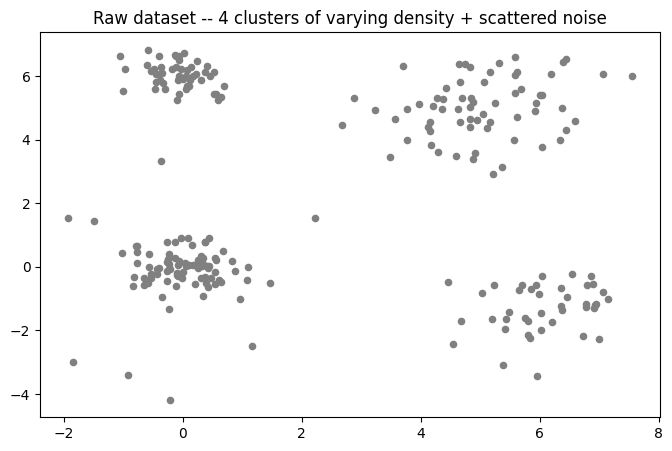

In [2]:
centers = [[0, 0], [5, 5], [0, 6], [6, -1]]
X, y_true = make_blobs(n_samples=[80, 60, 50, 40], centers=centers, cluster_std=[0.5, 0.9, 0.4, 0.7], random_state=11)

noise = np.random.uniform(low=X.min(axis=0)-1, high=X.max(axis=0)+1, size=(15, 2))
X = np.vstack([X, noise])

plt.scatter(X[:, 0], X[:, 1], s=20, color='gray')
plt.title('Raw dataset -- 4 clusters of varying density + scattered noise')
plt.show()


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 3. Step 1 — The k-distance Graph

For each point, compute the distance to its k-th nearest neighbor (k = a candidate `min_samples`),
sort ascending, and plot. The "elbow" is a strong candidate for `epsilon`.

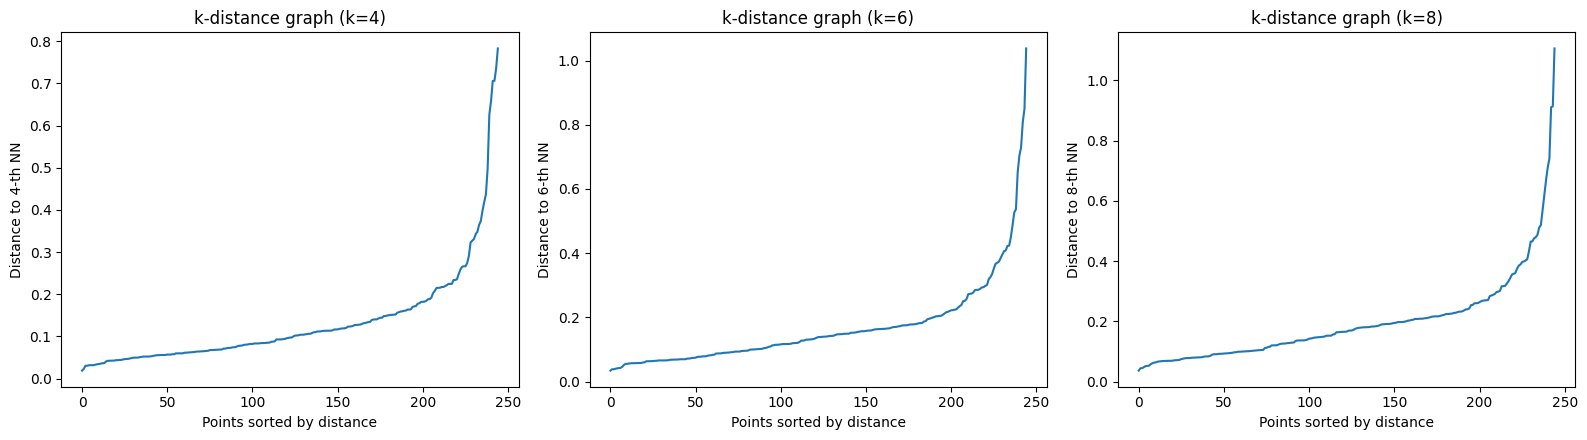

In [4]:
def plot_k_distance(X, k):
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors_fit = neighbors.fit(X)
    distances, _ = neighbors_fit.kneighbors(X)
    k_distances = np.sort(distances[:, -1])
    return k_distances

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, k in zip(axes, [4, 6, 8]):
    k_dist = plot_k_distance(X_scaled, k)
    ax.plot(k_dist)
    ax.set_title(f'k-distance graph (k={k})')
    ax.set_xlabel('Points sorted by distance')
    ax.set_ylabel(f'Distance to {k}-th NN')
plt.tight_layout()
plt.show()


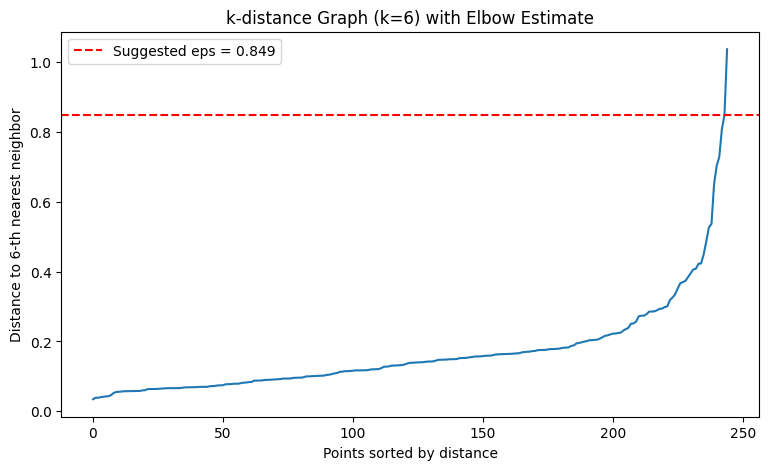

Starting epsilon estimate from k-distance graph: 0.849


In [5]:
def find_elbow(k_distances):
    """Find the point of maximum curvature (2nd derivative) as an elbow estimate."""
    first_deriv = np.diff(k_distances)
    second_deriv = np.diff(first_deriv)
    elbow_index = np.argmax(second_deriv) + 1
    return k_distances[elbow_index]

min_samples_candidate = 6
k_dist = plot_k_distance(X_scaled, min_samples_candidate)
suggested_eps = find_elbow(k_dist)

plt.figure(figsize=(9, 5))
plt.plot(k_dist)
plt.axhline(suggested_eps, color='red', linestyle='--', label=f'Suggested eps = {suggested_eps:.3f}')
plt.title(f'k-distance Graph (k={min_samples_candidate}) with Elbow Estimate')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'Distance to {min_samples_candidate}-th nearest neighbor')
plt.legend()
plt.show()

print(f"Starting epsilon estimate from k-distance graph: {suggested_eps:.3f}")


## 4. Step 2 — Fine-Tune with a Silhouette Score Sweep

The k-distance graph gives us a good **starting point**. Now let's sweep a range of `epsilon`
values around that estimate, and a few `min_samples` values, scoring each combination.

In [6]:
eps_range = np.arange(max(0.05, suggested_eps - 0.3), suggested_eps + 0.3, 0.05)
min_samples_range = [4, 6, 8, 10]

results = []
for ms in min_samples_range:
    for eps_val in eps_range:
        labels = DBSCAN(eps=eps_val, min_samples=ms).fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()

        if n_clusters > 1:
            try:
                score = silhouette_score(X_scaled, labels)
            except Exception:
                score = np.nan
        else:
            score = np.nan

        results.append({
            'eps': round(eps_val, 3),
            'min_samples': ms,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette_score': round(score, 3) if not np.isnan(score) else np.nan
        })

results_df = pd.DataFrame(results)
results_df.sort_values('silhouette_score', ascending=False).head(10)


,eps,min_samples,n_clusters,n_noise,silhouette_score
3,0.699,4,4,3,0.737
2,0.649,4,4,3,0.737
42,0.699,10,4,3,0.737
41,0.649,10,4,3,0.737
28,0.649,8,4,3,0.737
29,0.699,8,4,3,0.737
15,0.649,6,4,3,0.737
16,0.699,6,4,3,0.737
40,0.599,10,4,5,0.722
39,0.549,10,4,5,0.722


## 5. Pick the Best Combination and Visualize

Best combination found: eps=0.699, min_samples=4
-> 4 clusters, 3 noise points, silhouette=0.737


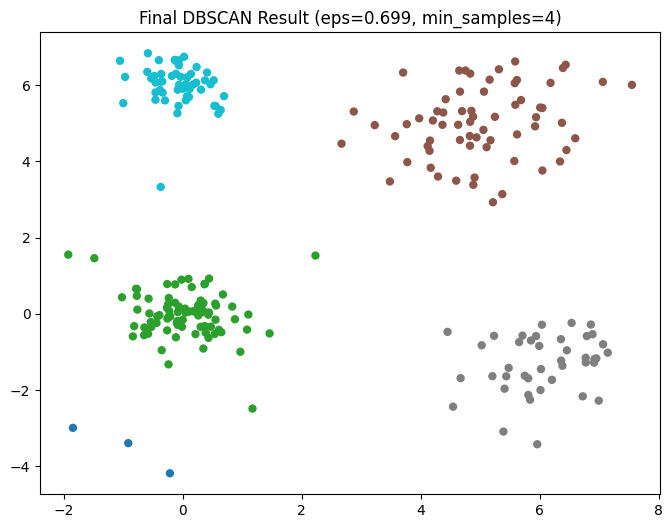

In [7]:
best_row = results_df.sort_values('silhouette_score', ascending=False).iloc[0]
best_eps = best_row['eps']
best_min_samples = int(best_row['min_samples'])

print(f"Best combination found: eps={best_eps}, min_samples={best_min_samples}")
print(f"-> {int(best_row['n_clusters'])} clusters, {int(best_row['n_noise'])} noise points, silhouette={best_row['silhouette_score']}")

final_labels = DBSCAN(eps=best_eps, min_samples=best_min_samples).fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=final_labels, cmap='tab10', s=25)
plt.title(f'Final DBSCAN Result (eps={best_eps}, min_samples={best_min_samples})')
plt.show()


## 6. Visualize How Silhouette Score Changes with Epsilon

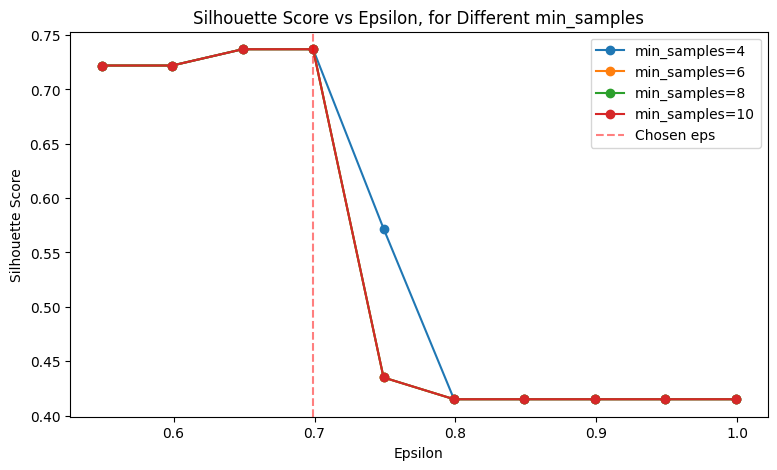

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
for ms in min_samples_range:
    subset = results_df[results_df['min_samples'] == ms].dropna(subset=['silhouette_score'])
    ax.plot(subset['eps'], subset['silhouette_score'], marker='o', label=f'min_samples={ms}')

ax.axvline(best_eps, color='red', linestyle='--', alpha=0.5, label='Chosen eps')
ax.set_xlabel('Epsilon')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score vs Epsilon, for Different min_samples')
ax.legend()
plt.show()


## 7. Key Takeaways

- The **k-distance graph** gives a principled *starting range* for `epsilon` -- much better than
  pure guesswork, especially once you have more than 2 features and can't just eyeball a scatter plot.
- A **silhouette score sweep** across a small grid of `epsilon` / `min_samples` values around that
  starting point lets you fine-tune systematically and pick a defensible final choice.
- This two-step workflow (k-distance graph -> silhouette sweep) is a solid, repeatable process you
  can apply to **any** new dataset before running DBSCAN "for real."

## 8. Try It Yourself

- Apply this exact workflow to the Mall Customers or Wholesale Customers datasets from the
  hierarchical clustering projects -- how does DBSCAN's result compare to what Agglomerative
  Clustering found there?
- Extend the grid search to more `min_samples` values, or use `GridSearchCV`-style automation.
- Try this on real, higher-dimensional data (more than 2 features) where you truly can't eyeball
  the right epsilon from a plot -- this is where this workflow becomes essential rather than just nice-to-have.
